## **I. Libraries and Data**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

## **II. EDA and Model Building**

In [5]:
# For visualization, we'll use only the first two features (sepal length and width)
X_vis = X[:, :2]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Visualization
X_train_vis, X_test_vis = train_test_split(X_vis, test_size=0.2, random_state=42)

In [6]:
# Euclidean distance function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [ ]:
# KNN from scratch function (using all features for prediction)
def knn_from_scratch(X_train, y_train, x_test, k=3):
    # Calculate distances from x_test to all points in X_train
    distances = []
    for i, x_train in enumerate(X_train):
        distance = euclidean_distance(x_train, x_test)
        distances.append((distance, y_train[i],i)) # tuple (distance, label, index)

    # Sort by distance ascending
    distances.sort(key=lambda x: x[0])
    # Get k nearest neighbors -> list slicing to take last k => :k
    k_nearest = distances[:k] # => Top k of x
    # Predict label by majority vote
    k_nearest_labels = [x[1] for x in k_nearest] #Take the label of k nearest points
    prediction = max(set(k_nearest_labels), key=k_nearest_labels.count) #Label with the most votes
    # Return distances and indices of k nearest
    distance_k = [neighbor[0] for neighbor in k_nearest]
    indeces_k = [neighbor[2] for neighbor in k_nearest]
    return distance_k, indeces_k, prediction

# KNN From Scratch: How It Works

This function predicts the segment label for a new data point ('x_test') based on its 
'k' nearest neighbors from the historical training data ('X_train', 'y_train').

## Step-by-Step Workflow:

### 1. Distance Calculation
- For each historical sample 'x_train' in 'X_train':
    * Calculate the Euclidean distance between 'x_train' and the new 'x_test'.
    * Store the result as a tuple: (distance, label, original_index).

### 2. Finding Neighbors
- Sort the entire 'distances' list in ascending order (closest neighbors first).
- Slice the list using '[:k]' to select the top 'k' closest neighbors (first 'k' elements).

### 3. Majority Voting
- Extract the labels of these 'k' nearest neighbors.
- Use 'max(set(labels), key=labels.count)' to count occurrences and select the label 
  with the majority vote. This becomes the final prediction.

### 4. Output Collection
- Extract the distances and indices of the chosen 'k' neighbors into separate lists.
- Return the neighbor distances, neighbor indices, and the final predicted label.


## **III. Model Prediction and Metrics**

In [8]:
# Predict on test set
y_pred = []
for x_test in X_test:
    _, _, pred = knn_from_scratch(X_train, y_train, x_test, k=3)
    y_pred.append(pred)

In [9]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Iris test set (k=3): {accuracy * 100:.2f}%")

Accuracy on Iris test set (k=3): 100.00%


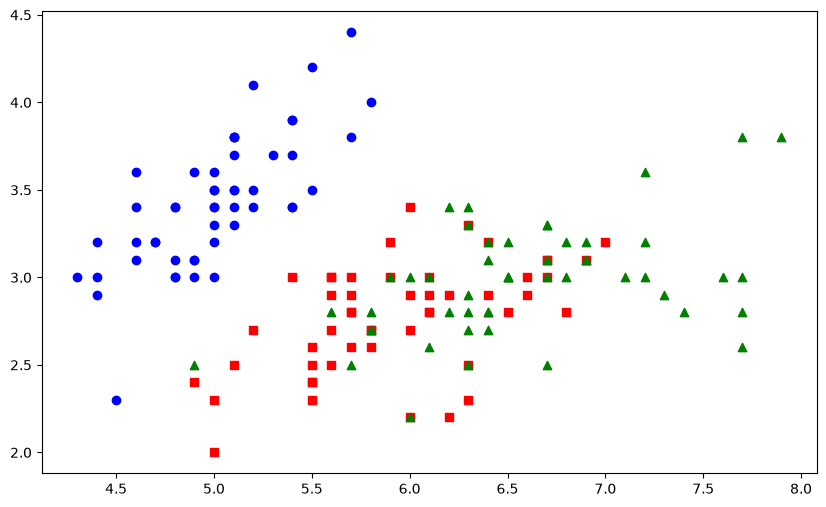

In [10]:
# Visualize the dataset (using first two features for 2D plot)
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']
for class_id in np.unique(y):
    plt.scatter(X_vis[y == class_id, 0], X_vis[y == class_id, 1],
                color=colors[class_id], marker=markers[class_id],
                label=iris.target_names[class_id])

C:\Users\PC\AppData\Local\Temp\ipykernel_29416\595328303.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


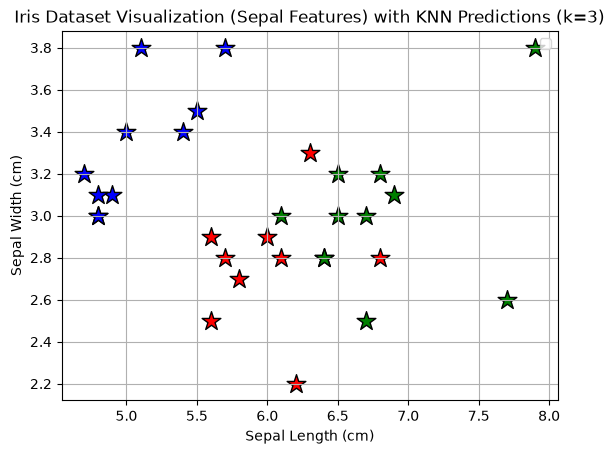

In [11]:
# Plot test points with predicted labels
for i, x_test_vis in enumerate(X_test_vis):
    plt.scatter(x_test_vis[0], x_test_vis[1], color=colors[y_pred[i]],
                marker='*', s=200, edgecolor='black')

plt.title("Iris Dataset Visualization (Sepal Features) with KNN Predictions (k=3)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Optional: Visualize decision boundary (meshgrid) using first two features for simplicity
# Train KNN on first two features for boundary visualization
def plot_decision_boundary(X_train_2d, y_train, k=3):
    h = 0.02  # Step size in mesh
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict for each point in mesh (using only 2 features)
    Z = np.array([knn_from_scratch(X_train_2d, y_train, np.array([x, y]), k=k)[2] for x, y in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    for class_id in np.unique(y_train):
        plt.scatter(X_train_2d[y_train == class_id, 0], X_train_2d[y_train == class_id, 1],
                    color=colors[class_id], marker=markers[class_id],
                    label=iris.target_names[class_id])
    plt.title("KNN Decision Boundary on Iris (Sepal Features, k=3)")
    plt.xlabel("Sepal Length (cm)")
    plt.ylabel("Sepal Width (cm)")
    plt.legend()
    plt.grid(True)
    plt.show()

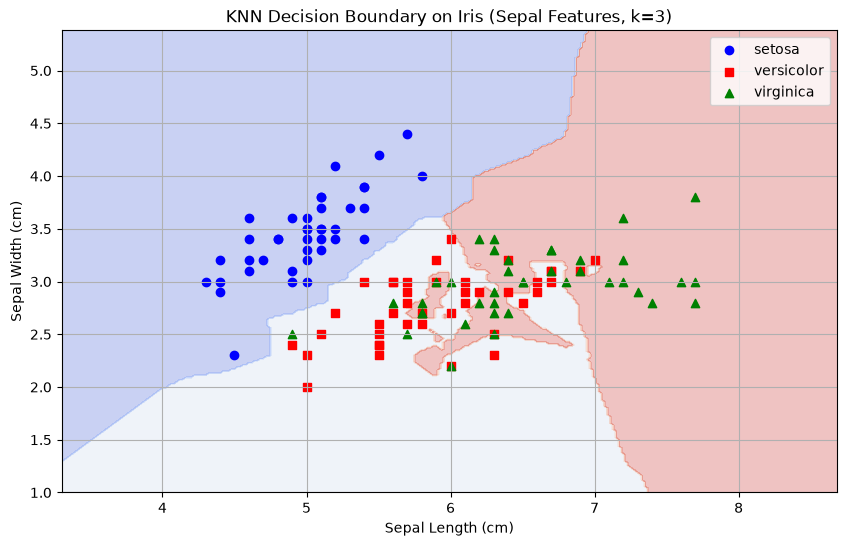

In [13]:
# Visualize decision boundary using first two features
X_train_vis = X_train[:, :2]  # Train on first two features for this plot
plot_decision_boundary(X_train_vis, y_train, k=3)